In [1]:
# MNIST + Simple Latent Diffusion Model (LDM)
'''
这是一个最小版的 Latent Diffusion Model 实验，思路是：

1. 先用 VAE 把 MNIST 图像编码到低维 latent space
2. 在 latent space 上训练一个简单的 Diffusion Model
3. 从随机噪声开始采样，逐步去噪，最终生成图像

这个实现适合学习 LDM 的核心流程，不追求非常强的生成质量。
'''

'\n这是一个最小版的 Latent Diffusion Model 实验，思路是：\n\n1. 先用 VAE 把 MNIST 图像编码到低维 latent space\n2. 在 latent space 上训练一个简单的 Diffusion Model\n3. 从随机噪声开始采样，逐步去噪，最终生成图像\n\n这个实现适合学习 LDM 的核心流程，不追求非常强的生成质量。\n'

In [2]:
import os
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


In [3]:
# ---------------------- 固定随机种子 ----------------------
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)


In [4]:
# ---------------------- 超参数 ----------------------
batch_size = 128
latent_dim = 32
vae_epochs = 5
diff_epochs = 20
lr_vae = 1e-3
lr_diff = 1e-3
T = 100

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [6]:
# ---------------------- MNIST 数据加载 ----------------------
from pathlib import Path

root_dir = Path('/Users/chris/Desktop/data')
if not root_dir.exists():
    root_dir = Path('/tmp/mnist_data')
    root_dir.mkdir(parents=True, exist_ok=True)

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root=str(root_dir), train=True, download=False, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"MNIST train samples: {len(train_dataset)}")
print(f"Data root: {root_dir}")

MNIST train samples: 60000
Data root: /Users/chris/Desktop/data


In [7]:
# ---------------------- VAE 模型 ----------------------
class VAE(nn.Module):
    def __init__(self, input_dim=784, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 2 * latent_dim)  # mu, log_var
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, input_dim),
            nn.Sigmoid()
        )
    def encode(self, x):
        enc_out = self.encoder(x)
        mu, log_var = torch.chunk(enc_out, 2, dim=1)
        z = self.reparameterize(mu, log_var)
        return z, mu, log_var

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + std * eps
    def forward(self, x):
        z, mu, log_var = self.encode(x)
        recon = self.decoder(z)
        return recon, mu, log_var
model_vae = VAE(input_dim=784, latent_dim=latent_dim).to(device)
optimizer_vae = optim.Adam(model_vae.parameters(), lr=lr_vae)

def vae_loss_function(x_recon, x, mu, log_var):
    recon_loss = F.binary_cross_entropy(x_recon, x, reduction="sum")
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + kl_loss, recon_loss, kl_loss


In [8]:
# ---------------------- 训练 VAE ----------------------
for epoch in range(vae_epochs):
    model_vae.train()
    total_loss = 0.0

    for imgs, _ in train_loader:
        x = imgs.view(-1, 784).to(device)
        optimizer_vae.zero_grad()

        x_recon, mu, log_var = model_vae(x)
        loss, recon_loss, kl_loss = vae_loss_function(x_recon, x, mu, log_var)

        loss.backward()
        optimizer_vae.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_dataset)
    print(f"VAE Epoch [{epoch + 1}/{vae_epochs}] Avg Loss: {avg_loss:.4f}")

VAE Epoch [1/5] Avg Loss: 166.5535
VAE Epoch [2/5] Avg Loss: 123.7291
VAE Epoch [3/5] Avg Loss: 115.8590
VAE Epoch [4/5] Avg Loss: 112.2588
VAE Epoch [5/5] Avg Loss: 110.1979


In [9]:
# ---------------------- 训练 Diffusion 的调度 ----------------------
betas = torch.linspace(1e-4, 0.02, T, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

print("beta schedule ready")

beta schedule ready


In [10]:
# ---------------------- 简单的 latent diffusion 模型 ----------------------
class LatentDiffusion(nn.Module):
    def __init__(self, latent_dim, timesteps=T):
        super().__init__()
        self.timesteps = timesteps
        self.net = nn.Sequential(
            nn.Linear(latent_dim + 1, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
    def forward(self, z_t, t):
        # t 是 batch 维度的时间步，归一化到 [0,1]
        t_input = t.float().unsqueeze(1) / self.timesteps
        x = torch.cat([z_t, t_input], dim=1)
        return self.net(x)

diff_model = LatentDiffusion(latent_dim=latent_dim, timesteps=T).to(device)
optimizer_diff = optim.Adam(diff_model.parameters(), lr=lr_diff)


In [11]:
# ---------------------- 训练 latent diffusion ----------------------
for epoch in range(diff_epochs):
    diff_model.train()
    total_loss = 0.0

    for imgs, _ in train_loader:
        x = imgs.view(-1, 784).to(device)

        with torch.no_grad():
            z0, _, _ = model_vae.encode(x)  # 取编码后的 latent z

        batch_size_now = x.size(0)
        t = torch.randint(0, T, (batch_size_now,), device=device)
        eps = torch.randn_like(z0)

        alpha_bar_t = alpha_bars[t].view(-1, 1)
        z_t = torch.sqrt(alpha_bar_t) * z0 + torch.sqrt(1.0 - alpha_bar_t) * eps

        pred_eps = diff_model(z_t, t)
        loss = F.mse_loss(pred_eps, eps)

        optimizer_diff.zero_grad()
        loss.backward()
        optimizer_diff.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_dataset)
    print(f"Diffusion Epoch [{epoch + 1}/{diff_epochs}] Avg Loss: {avg_loss:.4f}")


Diffusion Epoch [1/20] Avg Loss: 0.0063
Diffusion Epoch [2/20] Avg Loss: 0.0060
Diffusion Epoch [3/20] Avg Loss: 0.0059
Diffusion Epoch [4/20] Avg Loss: 0.0058
Diffusion Epoch [5/20] Avg Loss: 0.0058
Diffusion Epoch [6/20] Avg Loss: 0.0057
Diffusion Epoch [7/20] Avg Loss: 0.0057
Diffusion Epoch [8/20] Avg Loss: 0.0057
Diffusion Epoch [9/20] Avg Loss: 0.0057
Diffusion Epoch [10/20] Avg Loss: 0.0057
Diffusion Epoch [11/20] Avg Loss: 0.0057
Diffusion Epoch [12/20] Avg Loss: 0.0057
Diffusion Epoch [13/20] Avg Loss: 0.0057
Diffusion Epoch [14/20] Avg Loss: 0.0057
Diffusion Epoch [15/20] Avg Loss: 0.0056
Diffusion Epoch [16/20] Avg Loss: 0.0057
Diffusion Epoch [17/20] Avg Loss: 0.0056
Diffusion Epoch [18/20] Avg Loss: 0.0056
Diffusion Epoch [19/20] Avg Loss: 0.0056
Diffusion Epoch [20/20] Avg Loss: 0.0056


In [12]:
# ---------------------- 简单采样函数 ----------------------
@torch.no_grad()
def sample_latent_diffusion(model, vae, n_samples=16):
    z = torch.randn(n_samples, latent_dim, device=device)

    for t in reversed(range(T)):
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)
        pred_eps = model(z, t_batch)

        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]

        # DDPM 的简化采样公式
        mean = (z - ((1 - alpha_t) / (torch.sqrt(1 - alpha_bar_t))) * pred_eps) / torch.sqrt(alpha_t)

        if t > 0:
            alpha_bar_prev = alpha_bars[t - 1]
            noise = torch.randn_like(z)
            z = mean + torch.sqrt(1 - alpha_bar_prev) * noise
        else:
            z = mean
    gen_imgs = vae.decoder(z)
    gen_imgs = gen_imgs.view(-1, 28, 28).cpu()
    return gen_imgs

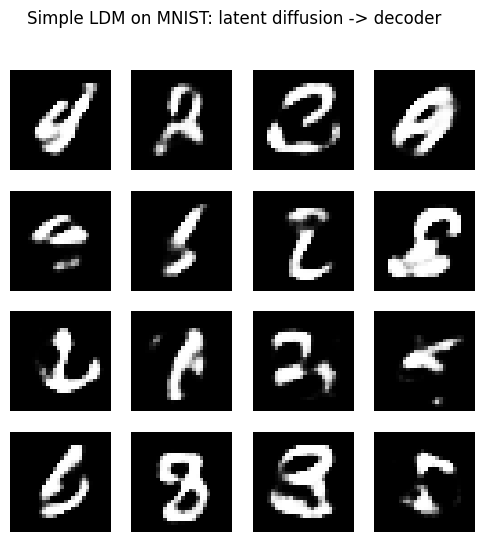

In [16]:
# ---------------------- 生成图像可视化 ----------------------
model_vae.eval()
diff_model.eval()

with torch.no_grad():
    generated = sample_latent_diffusion(diff_model, model_vae, n_samples=16)

plt.figure(figsize=(6, 6))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated[i], cmap="gray")
    plt.axis("off")
plt.suptitle("Simple LDM on MNIST: latent diffusion -> decoder")
plt.show()